# Description

It explores the context/tissue/cell type of the top samples associated with an LV.

Follow the notebook instructions below.

# Modules

In [1]:
import re
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from data.recount2 import LVAnalysis
from utils import chunker
import conf

# Settings

Specify below the LV id you are interested in:

In [2]:
LV_NAME = "LV802"

# Paths

These are paths to folder and files where we'll save our figures.

In [3]:
OUTPUT_FIGURES_DIR = Path(conf.RESULTS_DIR, "demo", f"{LV_NAME.lower()}").resolve()
display(OUTPUT_FIGURES_DIR)
OUTPUT_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

PosixPath('/opt/data/results/demo/lv802')

In [4]:
OUTPUT_CELL_TYPE_FILEPATH = OUTPUT_FIGURES_DIR / f"{LV_NAME.lower()}-cell_types.svg"
display(OUTPUT_CELL_TYPE_FILEPATH)

PosixPath('/opt/data/results/demo/lv802/lv802-cell_types.svg')

# Load MultiPLIER summary

In [5]:
multiplier_model_summary = pd.read_pickle(conf.MULTIPLIER["MODEL_SUMMARY_FILE"])

In [6]:
multiplier_model_summary.shape

(2157, 5)

In [7]:
multiplier_model_summary.head()

,pathway,LV index,AUC,p-value,FDR
1,KEGG_LYSINE_DEGRADATION,1,0.388059,0.866078,0.956005
2,REACTOME_MRNA_SPLICING,1,0.733057,0.000048,0.000582
3,MIPS_NOP56P_ASSOCIATED_PRE_RRNA_COMPLEX,1,0.680555,0.001628,0.011366
4,KEGG_DNA_REPLICATION,1,0.549473,0.312155,0.539951
5,PID_MYC_ACTIVPATHWAY,1,0.639303,0.021702,0.083739


# Load LV data

You can use the `LVAnalysis` class to explore an LV.

In [8]:
lv_obj = LVAnalysis(LV_NAME)

Here I show the top 20 genes for our LV. You can see gene symbols, the LV weight (in column `LV603`) and the cytoband.

In [9]:
lv_obj.lv_genes.head(20)

,gene_name,LV802,gene_band
0,ZNF441,5.156324,19p13.2
1,FBXL3,2.817947,13q22.3
2,TGFBR3,2.125792,1p22.1
3,TRPC1,2.026225,3q23
4,AXIN2,2.005983,17q24.1
5,SPRY1,1.996378,4q28.1
6,DECR2,1.850513,16p13.3
7,PPP1R12A,1.678663,12q21.31
8,PSD2,1.508566,5q31.2
9,SSX2IP,1.469982,1p22.3


Show the pathways our LV is aligned to (neutrophils):

In [10]:
multiplier_model_summary[
    multiplier_model_summary["LV index"].isin((LV_NAME[2:],))
    & (
        (multiplier_model_summary["FDR"] < 0.05)
        & (multiplier_model_summary["AUC"] >= 0.75)
    )
]

[2025-09-24 16:51:04,251 - numexpr.utils] INFO: Note: NumExpr detected 32 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 8.
[2025-09-24 16:51:04,252 - numexpr.utils] INFO: NumExpr defaulting to 8 threads.


,pathway,LV index,AUC,p-value,FDR


Here I load the LV metadata.
This is, for each sample from our matrix B, we load its metadata.
The `LVAnalysis` class takes care of downloading all necessary files from recount2.

In [11]:
lv_data = lv_obj.get_experiments_data()

SRP057196, SRP066834, SRP042161, SRP060416, SRP055569, SRP064464, SRP059379, SRP058773, SRP050499, SRP055153, SRP030617, SRP029889, SRP018853, SRP033369, SRP012461, SRP007947, SRP010670, SRP015853, SRP006474, SRP017411, SRP059170, SRP033135, SRP059775, SRP022892, SRP024268, SRP009862, SRP002487, SRP015449, SRP063980, SRP033646, SRP017777, SRP064259, SRP046749, SRP007461, SRP066424, SRP052056, SRP063840, SRP053190, SRP006575, SRP013363, SRP005279, SRP045859, SRP007412, SRP027530, 

/opt/code/libs/data/recount2.py:323: UserWarning: Not all experiments data could be loaded (42 != 44)
  warnings.warn(


In [12]:
lv_data.shape

(5747, 73)

In [13]:
lv_data.head()

tissue        cell type               age c1 chip id  \
project   run                                                                
SRP057196 SRR1975007  cortex  fetal_quiescent  prenatal 16-18 W  nochipID4   
          SRR1975008  cortex  fetal_quiescent  prenatal 16-18 W  nochipID4   
          SRR1975006  cortex  fetal_quiescent  prenatal 16-18 W  nochipID4   
          SRR1975005  cortex  fetal_quiescent  prenatal 16-18 W  nochipID4   
          SRR1975004  cortex  fetal_quiescent  prenatal 16-18 W  nochipID4   

                     experiment_sample_name Stage cell line patient id  \
project   run                                                            
SRP057196 SRR1975007                  FB_S6   NaN       NaN        NaN   
          SRR1975008                  FB_S6   NaN       NaN        NaN   
          SRR1975006                  FB_S6   NaN       NaN        NaN   
          SRR1975005                  FB_S6   NaN       NaN        NaN   
          SRR1975004                  FB_S6   NaN       NaN        NaN   

                     subtype tonsil donor  ... cell line stably expressing  \
project   run                              ...                               
SRP057196 SRR1975007     NaN          NaN  ...                         NaN   
          SRR1975008     NaN          NaN  ...                         NaN   
          SRR1975006     NaN          NaN  ...                         NaN   
          SRR1975005     NaN          NaN  ...                         NaN   
          SRR1975004     NaN          NaN  ...                         NaN   

                     par-clip antibody all lineage bcp all subtype  \
project   run                                                        
SRP057196 SRR1975007               NaN         NaN             NaN   
          SRR1975008               NaN         NaN             NaN   
          SRR1975006               NaN         NaN             NaN   
          SRR1975005               NaN         NaN             NaN   
          SRR1975004               NaN         NaN             NaN   

                     cytogenetic background disease state  \
project   run                                               
SRP057196 SRR1975007                    NaN           NaN   
          SRR1975008                    NaN           NaN   
          SRR1975006                    NaN           NaN   
          SRR1975005                    NaN           NaN   
          SRR1975004                    NaN           NaN   

                     ebv infection status tissue source tumor stage     LV802  
project   run                                                                  
SRP057196 SRR1975007                  NaN           NaN         NaN  0.028409  
          SRR1975008                  NaN           NaN         NaN -0.060717  
          SRR1975006                  NaN           NaN         NaN  0.180133  
          SRR1975005                  NaN           NaN         NaN -0.134242  
          SRR1975004                  NaN           NaN         NaN  0.026793  

[5 rows x 73 columns]

# LV cell types analysis

## Get top attributes

Here I quickly show the top attributes in our metadata for which we have the largest LV variance.
This is just to have an idea of the variance across different attributes

In [14]:
lv_attrs = lv_obj.get_attributes_variation_score()
display(lv_attrs.head(20))

c1 chip id                        0.071817
experiment_sample_name            0.071817
age                               0.063530
tissue                            0.030141
iPSc                              0.014084
time                              0.014084
reprogramming vector              0.014084
cell type                         0.012490
Stage                             0.012402
tonsil donor                      0.007030
facs gating                       0.007030
subtype                           0.006595
patient id                        0.006053
cohort                            0.005820
age (yrs)                         0.005820
well number                       0.005212
reprogramming time point (day)    0.005212
ercc_mix                          0.004786
ercc_dilution                     0.004786
cell count                        0.004786
dtype: float64

Since we are interested in cell types and tissues, the code below will find which attributes contain "cell type" or "tissue", so we can select from these results.

In [15]:
# show those with cell type or tissue in their name
_tmp = pd.Series(lv_attrs.index)
lv_attrs[
    _tmp.str.match(
        "(?:cell.*(type|line)$)|(?:tissue$)|(?:tissue.*type$)",
        case=False,
        flags=re.IGNORECASE,
    ).values
].sort_values(ascending=False)

tissue       0.030141
cell type    0.012490
cell line    0.002027
dtype: float64

Select from the output above those you are interested in. Usually all of them.

In [16]:
lv_attrs_selected = [
    "tissue",
    "cell type",
    "cell line",
]

In [17]:
_tmp = lv_data.loc[
    :,
    lv_attrs_selected + [LV_NAME],
]

In [18]:
_tmp_seq = list(chunker(_tmp.sort_values(LV_NAME, ascending=False), 25))

Now that we selected attributes that might be providing information about the cell type, we can see which are the top ones.

If you change the number in the cell below, you can paginate over the entire set of results; for example, with `_tmp_seq[1]` you'll see the next "page" in a descending order with respect to the LV value. So the ones at the top are the most important ones.

In [19]:
_tmp_seq[0]

tissue  \
project   run                                                             
SRP057196 SRR1974672                                             cortex   
          SRR1974546                                             cortex   
SRP066834 SRR2967736                                    Fetal neocortex   
          SRR2967518  Microdissected cortical-like ventricle from ce...   
          SRR2967480  Microdissected cortical-like ventricle from ce...   
SRP042161 SRR1294610                                                NaN   
SRP057196 SRR1974881                                             cortex   
SRP066834 SRR2967816                                    Fetal neocortex   
SRP060416 SRR2088159                                                NaN   
SRP055569 SRR1821506                                                NaN   
SRP060416 SRR2088320                                                NaN   
SRP057196 SRR1974744                                             cortex   
SRP066834 SRR2967788                                    Fetal neocortex   
SRP057196 SRR1974547                                             cortex   
SRP055569 SRR1821417                                                NaN   
SRP066834 SRR2967319                Dissociated whole cerebral organoid   
          SRR2967654                                    Fetal neocortex   
SRP057196 SRR1974927                                             cortex   
          SRR1975001                                             cortex   
SRP064464 SRR2558179                                                NaN   
SRP060416 SRR2088262                                                NaN   
          SRR2088237                                                NaN   
SRP066834 SRR2967550  Microdissected cortical-like ventricle from ce...   
          SRR2967310                Dissociated whole cerebral organoid   
SRP055569 SRR1821680                                                NaN   

                                                              cell type  \
project   run                                                             
SRP057196 SRR1974672                                         astrocytes   
          SRR1974546                                             hybrid   
SRP066834 SRR2967736                                                NaN   
          SRR2967518                                                NaN   
          SRR2967480                                                NaN   
SRP042161 SRR1294610                                       Glioblastoma   
SRP057196 SRR1974881                                  fetal_replicating   
SRP066834 SRR2967816                                                NaN   
SRP060416 SRR2088159                       tonsil Innate lymphoid cells   
SRP055569 SRR1821506  mixture of U87 human glioma cells and MCF10a h...   
SRP060416 SRR2088320                       tonsil Innate lymphoid cells   
SRP057196 SRR1974744                                         astrocytes   
SRP066834 SRR2967788                                                NaN   
SRP057196 SRR1974547                                             hybrid   
SRP055569 SRR1821417  mixture of U87 human glioma cells and MCF10a h...   
SRP066834 SRR2967319                                                NaN   
          SRR2967654                                                NaN   
SRP057196 SRR1974927                                    fetal_quiescent   
          SRR1975001                                    fetal_quiescent   
SRP064464 SRR2558179                                                NaN   
SRP060416 SRR2088262                       tonsil Innate lymphoid cells   
          SRR2088237                       tonsil Innate lymphoid cells   
SRP066834 SRR2967550                                                NaN   
          SRR2967310                                                NaN   
SRP055569 SRR1821680                   MCF10a human breast cancer cells   

             

You can see above that the RNA-seq samples are from neutrophils or granulocytes.
If we move to the next "page", we'll see this:

In [20]:
_tmp_seq[1]

tissue  \
project   run                           
SRP042161 SRR1294515              NaN   
SRP057196 SRR1974872           cortex   
SRP042161 SRR1295241              NaN   
SRP055569 SRR1821561              NaN   
SRP059379 SRR2060562              NaN   
SRP042161 SRR1294672              NaN   
SRP060416 SRR2088346              NaN   
SRP057196 SRR1974716           cortex   
          SRR1974607           cortex   
          SRR1974743           cortex   
SRP042161 SRR1295060              NaN   
SRP057196 SRR1974954           cortex   
          SRR1974707           cortex   
          SRR1974550           cortex   
SRP042161 SRR1294673              NaN   
SRP057196 SRR1974640           cortex   
SRP058773 SRR2042655              NaN   
SRP066834 SRR2967713  Fetal neocortex   
SRP055569 SRR1821642              NaN   
          SRR1821523              NaN   
SRP050499 SRR2013719              NaN   
SRP060416 SRR2088392              NaN   
SRP055569 SRR1821516              NaN   
SRP066834 SRR2967649  Fetal neocortex   
SRP060416 SRR2088257              NaN   

                                                              cell type  \
project   run                                                             
SRP042161 SRR1294515                                       Glioblastoma   
SRP057196 SRR1974872                                            neurons   
SRP042161 SRR1295241                             Gliomasphere Cell Line   
SRP055569 SRR1821561  mixture of U87 human glioma cells and MCF10a h...   
SRP059379 SRR2060562                       iPSC-derived cortical neuron   
SRP042161 SRR1294672                                       Glioblastoma   
SRP060416 SRR2088346                       tonsil Innate lymphoid cells   
SRP057196 SRR1974716                                             hybrid   
          SRR1974607                                            neurons   
          SRR1974743                                         astrocytes   
SRP042161 SRR1295060                                       Glioblastoma   
SRP057196 SRR1974954                                    fetal_quiescent   
          SRR1974707                                            neurons   
          SRR1974550                                             hybrid   
SRP042161 SRR1294673                                       Glioblastoma   
SRP057196 SRR1974640                                            neurons   
SRP058773 SRR2042655                                                NaN   
SRP066834 SRR2967713                                                NaN   
SRP055569 SRR1821642                   MCF10a human breast cancer cells   
          SRR1821523  mixture of U87 human glioma cells and MCF10a h...   
SRP050499 SRR2013719                                                NaN   
SRP060416 SRR2088392                       tonsil Innate lymphoid cells   
SRP055569 SRR1821516  mixture of U87 human glioma cells and MCF10a h...   
SRP066834 SRR2967649                                                NaN   
SRP060416 SRR2088257                       tonsil Innate lymphoid cells   

                     cell line     LV802  
project   run                             
SRP042161 SRR1294515       NaN  0.373416  
SRP057196 SRR1974872       NaN  0.366781  
SRP042161 SRR1295241      CSC6  0.365430  
SRP055569 SRR1821561       NaN  0.356017  
SRP059379 SRR2060562       NaN  0.344337  
SRP042161 SRR1294672       NaN  0.341261  
SRP060416 SRR2088346       NaN  0.340827  
SRP057196 SRR1974716       NaN  0.339347  
          SRR1974607       NaN  0.339060  
          SRR1974743       NaN  0.338507  
SRP042161 SRR1295060       NaN  0.337964  
SRP057196 SRR1974954       NaN  0.336270  
          SRR1974707       NaN  0.333939  
          SRR1974550       NaN  0.331419  
SRP042161 SRR1294673       NaN  0.327355  
SRP057196 SRR1974640       NaN  0.327206  
SRP058773 SRR2042655       NaN  0.320819  
SRP066834 SRR2967713       NaN  0.315530  
SRP055569 SRR1821642       NaN  0.303

Although the attributes we selected (`cell type`, `celltype` and `tissue`) seem to be enough for most of the RNA-seq samples to get their cell types, this is not the case for some of them. For example, we have empty values (NaN) for `SRP015360`.

You can explore the metadata provided for a particular SPR with the code below. Let's see what we have in `SRP015360`:

In [21]:
# list the top 10 samples from this project
lv_data.loc[["SRP035864"]].dropna(how="all", axis=1).sort_values(
    LV_NAME, ascending=False
).head(10)

KeyError: "['SRP035864'] not in index"

So for `SRP015360` we only have three attributes: `age`, `Sex` and `treatment`. No cell type information. Here you can start grasping the challenges in analyzing this data.

If you are really interested in this metadata for this project, you can use this URL:
```
https://trace.ncbi.nlm.nih.gov/Traces/sra/?study=SRP015360
```
where you can put the SRP code you want. If you check the URL above, you'll see that these samples were taken from neutrophils as well (treated with different stimuli), although we don't have metadata about the cell type/tissue.

Ok, we do not want several attributes conveying the same information (cell types), just a single one, so here we'll combine the attributes we found before with a particular _order_.
In this case I select `cell type` _first_ (the order is important), `celltype` as second, and `tissue` as third/last.
This means that I will use the information in `cell type` first, but if this is empty (as in `SRP045500`), we'll try with `celltype`, and so on.

In [22]:
SELECTED_ATTRIBUTES = [
    "tissue",
    "cell type",
    "cell line",
]

## Get a single attribute with "cell type/tissue" information

In [23]:
plot_data = lv_data.loc[:, SELECTED_ATTRIBUTES + [LV_NAME]]

In [24]:
# if blank/nan, fill cell type column with tissue content
_new_column = plot_data[SELECTED_ATTRIBUTES].fillna(method="backfill", axis=1)[
    SELECTED_ATTRIBUTES[0]
]
plot_data[SELECTED_ATTRIBUTES[0]] = _new_column
plot_data = plot_data.drop(columns=SELECTED_ATTRIBUTES[1:])
plot_data = plot_data.fillna({SELECTED_ATTRIBUTES[0]: "NOT CATEGORIZED"})

In [25]:
plot_data = plot_data.sort_values(LV_NAME, ascending=False)

In [26]:
plot_data.head(20)

tissue  \
project   run                                                             
SRP057196 SRR1974672                                             cortex   
          SRR1974546                                             cortex   
SRP066834 SRR2967736                                    Fetal neocortex   
          SRR2967518  Microdissected cortical-like ventricle from ce...   
          SRR2967480  Microdissected cortical-like ventricle from ce...   
SRP042161 SRR1294610                                       Glioblastoma   
SRP057196 SRR1974881                                             cortex   
SRP066834 SRR2967816                                    Fetal neocortex   
SRP060416 SRR2088159                       tonsil Innate lymphoid cells   
SRP055569 SRR1821506  mixture of U87 human glioma cells and MCF10a h...   
SRP060416 SRR2088320                       tonsil Innate lymphoid cells   
SRP057196 SRR1974744                                             cortex   
SRP066834 SRR2967788                                    Fetal neocortex   
SRP057196 SRR1974547                                             cortex   
SRP055569 SRR1821417  mixture of U87 human glioma cells and MCF10a h...   
SRP066834 SRR2967319                Dissociated whole cerebral organoid   
          SRR2967654                                    Fetal neocortex   
SRP057196 SRR1974927                                             cortex   
          SRR1975001                                             cortex   
SRP064464 SRR2558179                                    NOT CATEGORIZED   

                         LV802  
project   run                   
SRP057196 SRR1974672  5.036361  
          SRR1974546  1.607870  
SRP066834 SRR2967736  1.518891  
          SRR2967518  0.942720  
          SRR2967480  0.902708  
SRP042161 SRR1294610  0.816183  
SRP057196 SRR1974881  0.749466  
SRP066834 SRR2967816  0.734912  
SRP060416 SRR2088159  0.731956  
SRP055569 SRR1821506  0.678397  
SRP060416 SRR2088320  0.647942  
SRP057196 SRR1974744  0.562801  
SRP066834 SRR2967788  0.508436  
SRP057196 SRR1974547  0.478357  
SRP055569 SRR1821417  0.469045  
SRP066834 SRR2967319  0.466788  
          SRR2967654  0.441810  
SRP057196 SRR1974927  0.440593  
          SRR1975001  0.420578  
SRP064464 SRR2558179  0.420184

You can see that now all attributes ("celltype", "cell type" and "tissue") are combined under a single attribute named "cell type".
For example, if you look at `SRP045500`, which had a value under "celltype" but an empty (NaN) value for attribute "cell type", that now the value was moved to "cell type" (it was unified into this single attribute).

If you see "NOT CATEGORIZED", it means that none of the attributes you used had a value (they were all empty or NaN). In this case you would go the URL before and read the article/RNA-seq data description to find out the cell type or tissue (or whatever attribute your are interested in).

## Standardize cell type names

When cell type values are different but represent the same cell type, we unify them:

In [27]:
final_plot_data = plot_data.replace(
    {
        SELECTED_ATTRIBUTES[0]: {
            # # neutrophils:
            # "primary human neutrophils": "Neutrophils",
            # "Neutrophil isolated from peripheral blood": "Neutrophils",
            # "Neutrophil": "Neutrophils",
            # "neutrophils (Neu)": "Neutrophils",
            # # granulocytes:
            # "granulocyte": "Granulocytes",
            # # monocytes:
            # "primary human monocytes": "Monocytes",
            # # whole blood:
            # #             "whole blood": "Whole blood",  # uncomment this line to merge occurences of "whole blood" into "Whole blood"
            # "Whole Blood": "Whole blood",
            # # PBMC:
            # "primary human PBMC": "PBMC",
            # # B-cells:
            # "primary human B cells": "B cells",
            # # T-cells:
            # "primary human T cells": "T cells",
            # # epithelial cells:
            # "epithelial cells (Epi)": "Epithelial cells",
            # "primary human myeloid DC": "mDCs",
        }
    }
)

The code below is more advanced, but you can use it to customize even further your final attribute value (for example, if you want to use the cell type, but put the treatment name with parenthesis).

In [28]:
# # add also tissue information to these projects
# _srp_code = "SRP061881"
# _tmp = final_plot_data.loc[(_srp_code,)].apply(
#     lambda x: lv_data.loc[(_srp_code, x.name), "cell type"]
#     + f" ({lv_data.loc[(_srp_code, x.name), 'tissue']})",
#     axis=1,
# )
# final_plot_data.loc[(_srp_code, _tmp.index), SELECTED_ATTRIBUTES[0]] = _tmp.values

In [29]:
# # all samples from SRP015360 are neutrophils
# final_plot_data[SELECTED_ATTRIBUTES[0]] = final_plot_data.apply(
#     lambda x: "Neutrophils" if x.name[0] in ("SRP015360",) else x[SELECTED_ATTRIBUTES[0]],
#     axis=1,
# )

In [30]:
final_plot_data = final_plot_data.sort_values(LV_NAME, ascending=False)

## Threshold LV values

The code below is useful in case you want to put a threshold to the plot (for example, you have same samples with very high values).

In [31]:
# final_plot_data.loc[
#     final_plot_data[LV_NAME] > LV_AXIS_THRESHOLD, LV_NAME
# ] = LV_AXIS_THRESHOLD

## Delete samples with no tissue/cell type information

If you are not interested in samples for which we couldn't find cell type/tissue information, you can delete them by uncommenting the code below.
However, if you want, you can take a look at those later (we'll show you how at the end).

In [32]:
# final_plot_data = final_plot_data[
#     final_plot_data[SELECTED_ATTRIBUTE] != "NOT CATEGORIZED"
# ]

## Set top cell types to show

In [33]:
N_TOP_ATTRS = 10

In [34]:
attr_order = (
    final_plot_data.groupby(SELECTED_ATTRIBUTES[0])
    .max()
    .sort_values(LV_NAME, ascending=False)
    .index[:N_TOP_ATTRS]
    .tolist()
)

In [35]:
len(attr_order)

10

In [36]:
attr_order[:5]

['cortex',
 'Fetal neocortex',
 'Microdissected cortical-like ventricle from cerebral organoid',
 'Glioblastoma',
 'tonsil Innate lymphoid cells']

# Plot

Now we create the plot with RNA-seq samples as points, cell types in the x-axis, and the LV value in the y-axis.
This shows you in which cell types genes in LV603 are primirily expressed.

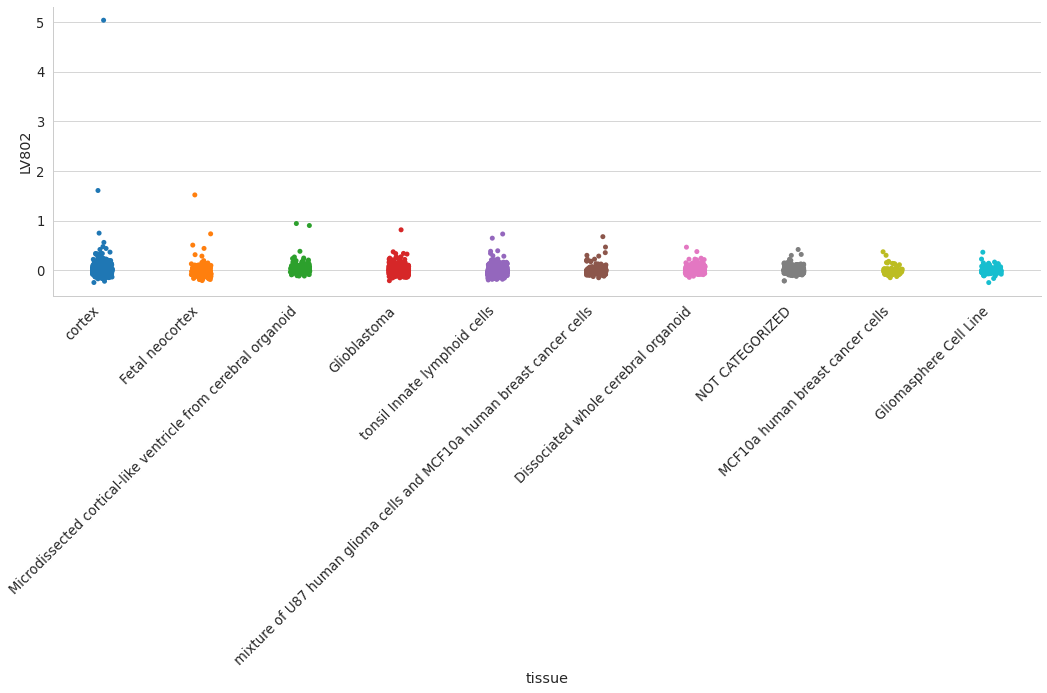

In [37]:
with sns.plotting_context("paper", font_scale=1.5), sns.axes_style("whitegrid"):
    sns.catplot(
        data=final_plot_data,
        y=LV_NAME,
        x=SELECTED_ATTRIBUTES[0],
        order=attr_order,
        kind="strip",
        height=5,
        aspect=3,
    )
    plt.xticks(rotation=45, horizontalalignment="right")

    # You can save the figure if you uncomment the code below
    # the figure will be created under ${DATA_FOLDER}/results/demo

    plt.savefig(
        OUTPUT_CELL_TYPE_FILEPATH,
        bbox_inches="tight",
        facecolor="white",
    )

# Debug

Now that you have the figure for your LV, you can debug some things.
For example, you'll see above that some samples are "NOT CATEGORIZED".
Let's see which are those:

In [42]:
with pd.option_context(
    "display.max_rows", None, "display.max_columns", None, "display.max_colwidth", None
):
    _tmp = final_plot_data[
        final_plot_data[SELECTED_ATTRIBUTES[0]].str.contains("normal")
    ]
    display(_tmp.head(20))

tissue type      LV71
project   run                                                
SRP012656 SRR493954                          normal  1.446472
          SRR493953                          normal  1.444617
          SRR493946                          normal  1.316323
          SRR493945                          normal  1.315039
          SRR493958                          normal  1.277137
          SRR493957                          normal  1.274951
          SRR493941                          normal  1.253232
          SRR493942                          normal  1.252572
          SRR493950                          normal  0.948464
          SRR493949                          normal  0.939736
SRP032833 SRR1027988  surrounding normal lung (nor)  0.769324
SRP012656 SRR493938                          normal  0.690146
          SRR493937                          normal  0.684582
SRP032833 SRR1027985  surrounding normal lung (nor)  0.492776
SRP049097 SRR1617451                    normal lung  0.491245
          SRR1617450                    normal lung  0.488778
SRP032833 SRR1027997  surrounding normal lung (nor)  0.443310
          SRR1028000  surrounding normal lung (nor)  0.424049
          SRR1027994  surrounding normal lung (nor)  0.418608
SRP049097 SRR1617457           normal smooth muscle  0.090525

We don't have information about cell type/tissue for these.
But we can manually go to the URL showed before and check out.
For example, for `SRP015360` we can open our browser with this URL:
https://trace.ncbi.nlm.nih.gov/Traces/sra/?study=SRP012461, and see that the samples were taken from neutrophils.

If you need to see which information is provided by each SRP, you can again use the code below:

In [43]:
# what is there in these projects?
lv_data.loc[["SRP012656"]].dropna(how="all", axis=1).sort_values(
    LV_NAME, ascending=False
).head(60)

disease patient tissue type Stage  gender  \
project   run                                                                  
SRP012656 SRR493954  Adenocarcinoma, NSCLC       6      normal    IB  female   
          SRR493953  Adenocarcinoma, NSCLC       6      normal    IB  female   
          SRR493946  Adenocarcinoma, NSCLC       4      normal    IB  female   
          SRR493945  Adenocarcinoma, NSCLC       4      normal    IB  female   
          SRR493958  Adenocarcinoma, NSCLC       8      normal    IB  female   
          SRR493957  Adenocarcinoma, NSCLC       8      normal    IB  female   
          SRR493941  Adenocarcinoma, NSCLC       3      normal    IB  female   
          SRR493942  Adenocarcinoma, NSCLC       3      normal    IB  female   
          SRR493950  Adenocarcinoma, NSCLC       5      normal    IB  female   
          SRR493949  Adenocarcinoma, NSCLC       5      normal    IB  female   
          SRR493938  Adenocarcinoma, NSCLC       1      normal    IB  female   
          SRR493937  Adenocarcinoma, NSCLC       1      normal    IB  female   
          SRR493947  Adenocarcinoma, NSCLC       4       tumor    IA  female   
          SRR493948  Adenocarcinoma, NSCLC       4       tumor    IA  female   
          SRR493959  Adenocarcinoma, NSCLC       8       tumor    IA  female   
          SRR493960  Adenocarcinoma, NSCLC       8       tumor    IA  female   
          SRR493940  Adenocarcinoma, NSCLC       1       tumor   IIA  female   
          SRR493939  Adenocarcinoma, NSCLC       1       tumor   IIA  female   
          SRR493956  Adenocarcinoma, NSCLC       6       tumor   IIB  female   
          SRR493955  Adenocarcinoma, NSCLC       6       tumor   IIB  female   
          SRR493951  Adenocarcinoma, NSCLC       5       tumor   IIA  female   
          SRR493952  Adenocarcinoma, NSCLC       5       tumor   IIA  female   
          SRR493944  Adenocarcinoma, NSCLC       3       tumor   IIB  female   
          SRR493943  Adenocarcinoma, NSCLC       3       tumor   IIB  female   
          SRR493965  Adenocarcinoma, NSCLC       4      normal    IB  female   
          SRR493961  Adenocarcinoma, NSCLC       1      normal    IB  female   
          SRR493971  Adenocarcinoma, NSCLC       8      normal    IB  female   
          SRR493966  Adenocarcinoma, NSCLC       4       tumor    IA  female   
          SRR493969  Adenocarcinoma, NSCLC       6      normal    IB  female   
          SRR493962  Adenocarcinoma, NSCLC       1       tumor   IIA  female   
          SRR493972  Adenocarcinoma, NSCLC       8       tumor    IA  female   
          SRR493970  Adenocarcinoma, NSCLC       6       tumor   IIB  female   
          SRR493963  Adenocarcinoma, NSCLC       3      normal    IB  female   
          SRR493967  Adenocarcinoma, NSCLC       5      normal    IB  female   
          SRR493968  Adenocarcinoma, NSCLC       5       tumor   IIA  female   
          SRR493964  Adenocarcinoma, NSCLC       3       tumor   IIB  female   

                          age      smoker      LV71  
project   run                                        
SRP012656 SRR493954  70 years  non-smoker  1.446472  
          SRR493953  70 years  non-smoker  1.444617  
          SRR493946  60 years  non-smoker  1.316323  
          SRR493945  60 years  non-smoker  1.315039  
          SRR493958  62 years  non-smoker  1.277137  
          SRR493957  62 years  non-smoker  1.274951  
          SRR493941  53 years  non-smoker  1.253232  
          SRR493942  53 years  non-smoker  1.252572  
          SRR493950  44 years  non-smoker  0.948464  
          SRR493949  44 years  non-smoker  0.939736  
          SRR493938  44 years  non-smoker  0.690146  
          SRR493937  44 years  non-smoker  0.684582  
          SRR493947  60 years  non-smoker  0.582171  
          SRR493948  60 years  non-smoker  0.577654  
          SRR493959  62 years  non-smoker  0.553508  
          SRR493960  62 years  non-smoker  0.552147  
          SRR493940  4

Now you can go back to section `Standardize cell type names` in this notebook and adjust according to this findings to improve the figure.
Once you are happy, you can remove the `NOT CATEGORIZED` items by uncommenting the code in `Delete samples with no tissue/cell type information`.